# Manifest stats (splits)


In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
MANIFEST_DIR = DATA_DIR / "manifests"
EXPORT_DIR = PROJECT_ROOT / "notebooks" / "data" / "manifest-stats"

TASK_TARGETS = {
    "trick_classification": "trick",
    "score_prediction": "execution_score",
    "score_prediction_binary": "quality_label",
    "score_prediction_ordinal": "execution_score",
    "score_prediction_rank": "pair_label",
}

EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [10]:
def task_name_from_dir(task_dir):
    return task_dir.name.replace("_", "-")


def load_vocab(task_dir):
    vocab_path = task_dir / "vocab.json"
    if not vocab_path.exists():
        return {}
    with vocab_path.open() as f:
        return json.load(f)


def discover_task_configs(manifest_dir):
    task_configs = {}
    for task_dir in sorted(manifest_dir.iterdir()):
        if not task_dir.is_dir() or task_dir.name not in TASK_TARGETS:
            continue
        target = TASK_TARGETS[task_dir.name]
        vocab = load_vocab(task_dir)
        task_configs[task_name_from_dir(task_dir)] = {
            "dir": task_dir.name,
            "target": target,
            "target_order": vocab.get(target, {}).get("labels"),
        }
    return task_configs


def load_task_manifest(task_dir):
    split_paths = {
        "train": task_dir / "train.jsonl",
        "val": task_dir / "val.jsonl",
        "test": task_dir / "test.jsonl",
    }
    split_frames = {}
    for split, path in split_paths.items():
        if not path.exists():
            raise FileNotFoundError(
                f"Missing manifest: {path}. Run the data pipeline first."
            )
        df = pd.read_json(path, lines=True)
        df["split"] = split
        split_frames[split] = df

    manifest_df = pd.concat(split_frames.values(), ignore_index=True)
    return manifest_df, split_frames


def target_counts(df, target_col, target_order=None):
    counts = df[target_col].value_counts().sort_index()
    if target_order:
        counts.index = counts.index.astype(str)
        counts = counts.reindex(target_order, fill_value=0)
    return counts


In [11]:
task_configs = discover_task_configs(MANIFEST_DIR)
task_manifests = {}
for task_name, task_cfg in task_configs.items():
    task_dir = MANIFEST_DIR / task_cfg["dir"]
    manifest_df, split_frames = load_task_manifest(task_dir)
    task_manifests[task_name] = {
        "manifest_df": manifest_df,
        "split_frames": split_frames,
    }

    print(f"Task: {task_name}")
    print("Rows per split:")
    for split, df in split_frames.items():
        print(f"  {split}: {len(df)}")
    print("Target counts (all):")
    counts = target_counts(
        manifest_df,
        task_cfg["target"],
        target_order=task_cfg.get("target_order"),
    )
    print(counts)
    print()


Task: score-prediction
Rows per split:
  train: 455
  val: 58
  test: 57
Target counts (all):
execution_score
0.25     24
0.50    166
0.75    219
1.00    161
Name: count, dtype: int64

Task: score-prediction-binary
Rows per split:
  train: 320
  val: 40
  test: 41
Target counts (all):
quality_label
bad     162
good    239
Name: count, dtype: int64

Task: score-prediction-ordinal
Rows per split:
  train: 792
  val: 100
  test: 100
Target counts (all):
execution_score
1    197
2    500
3    295
Name: count, dtype: int64

Task: score-prediction-rank
Rows per split:
  train: 249
  val: 32
  test: 32
Target counts (all):
pair_label
left     159
right    154
Name: count, dtype: int64

Task: trick-classification
Rows per split:
  train: 792
  val: 100
  test: 100
Target counts (all):
trick
ao-soul       157
bs-royale     152
fs-royale     154
fs-savanah    147
mizou         120
soul          121
top-soul      141
Name: count, dtype: int64



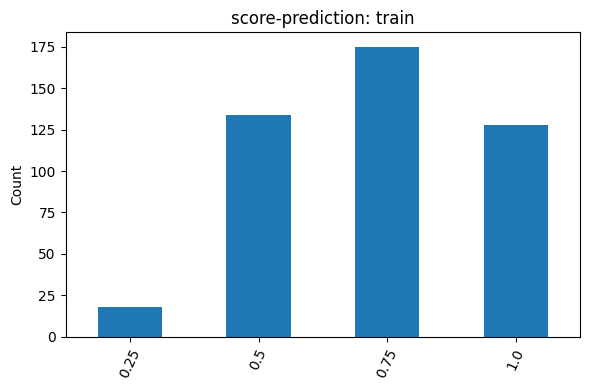

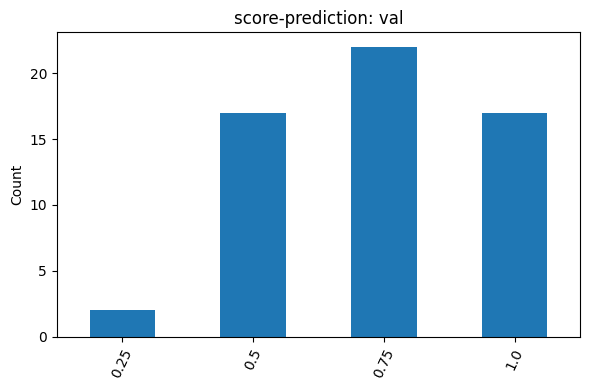

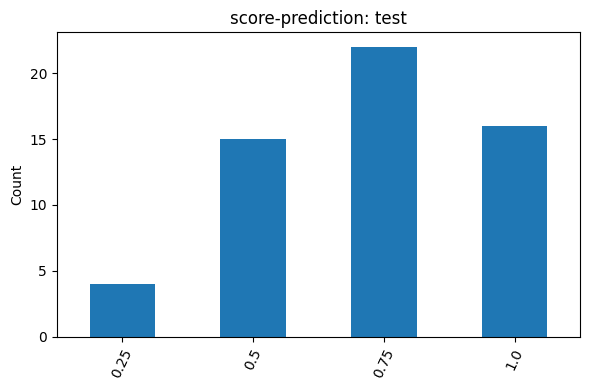

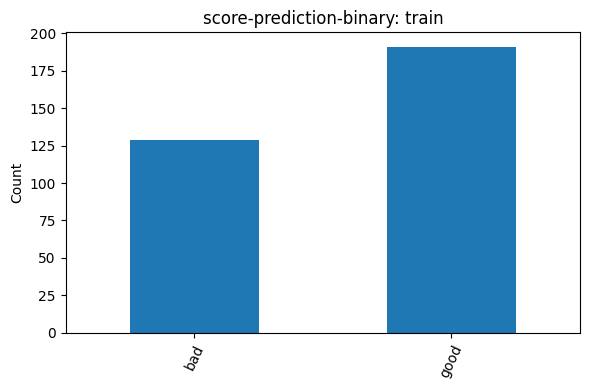

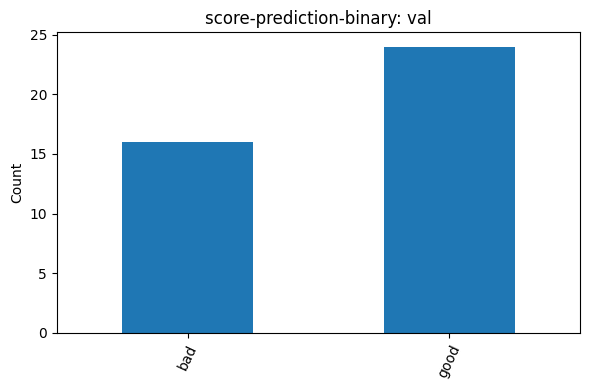

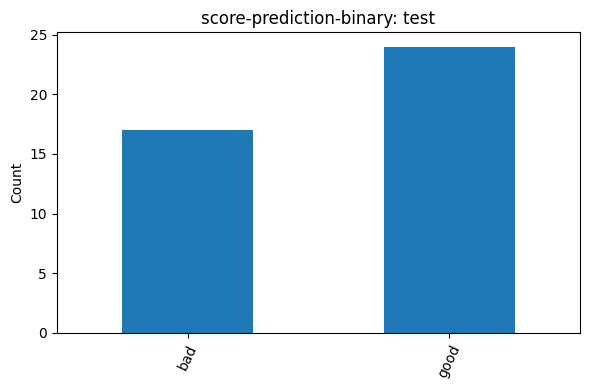

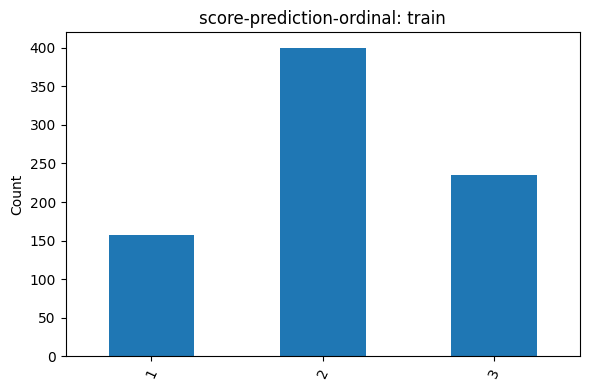

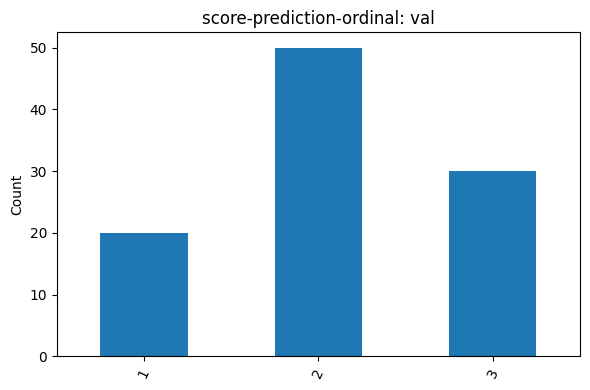

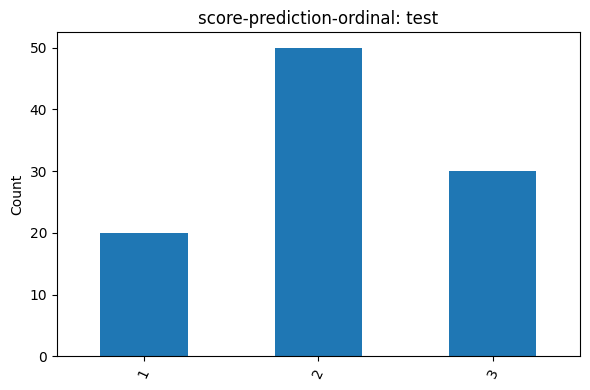

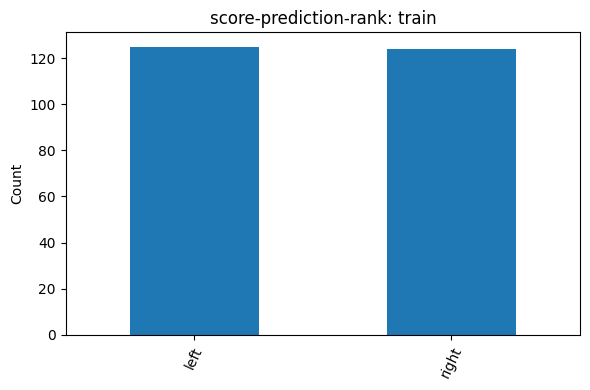

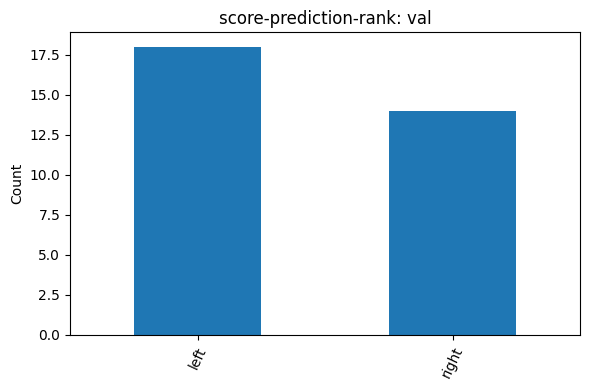

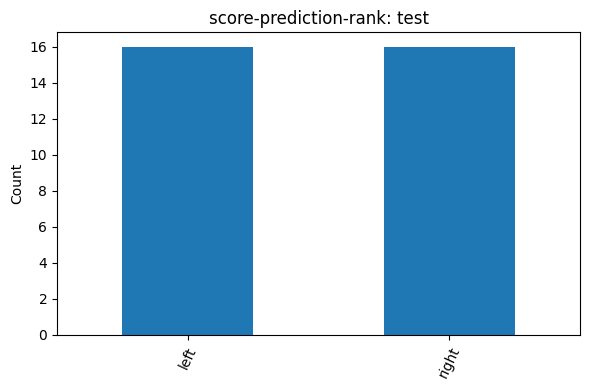

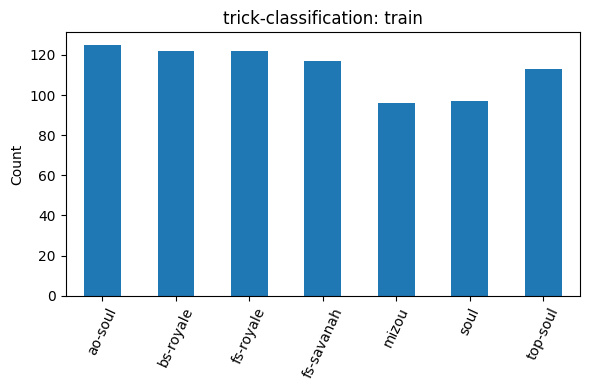

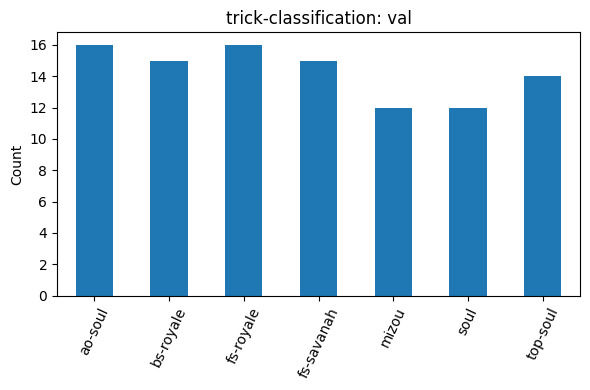

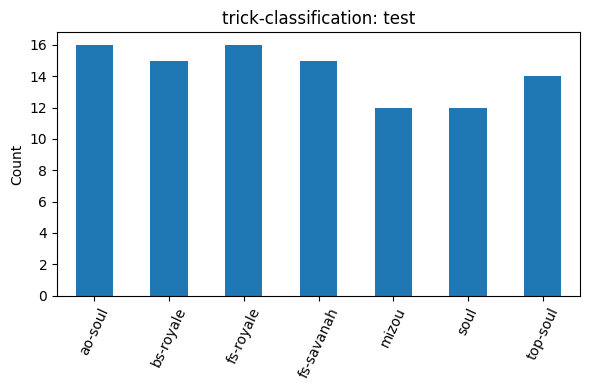

In [12]:
for task_name, task_cfg in task_configs.items():
    split_frames = task_manifests[task_name]["split_frames"]
    target_col = task_cfg["target"]

    task_export_dir = EXPORT_DIR / task_name
    task_export_dir.mkdir(parents=True, exist_ok=True)

    for split in ["train", "val", "test"]:
        df = split_frames[split]
        counts = target_counts(
            df,
            target_col,
            target_order=task_cfg.get("target_order"),
        )

        fig, ax = plt.subplots(figsize=(6, 4))
        counts.plot(kind="bar", ax=ax)
        ax.set_title(f"{task_name}: {split}")
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=65)

        fig.tight_layout()
        fig.savefig(task_export_dir / f"{split}-dist.png")
        plt.show()
